# **Initialization**

In [ ]:
import torch
import random

In [ ]:
import transformers
import datasets
import sklearn
import pandas
import matplotlib
import seaborn


In [ ]:
#Code for reproducibility
SEEDS = [42, 1234]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.deterministic = True

print("PyTorch Version: ", torch.__version__)
print(f"Using {'GPU' if str(DEVICE) == 'cuda' else 'CPU'}.")
print("Seeds:", SEEDS)


PyTorch Version:  2.10.0+cu128
Using GPU.
Seeds: [42, 1234]


In [ ]:
#Loading datasets required from surrey #
from datasets import load_dataset

ds = load_dataset("surrey-nlp/BESSTIE-CW-26")

print(ds)
print(ds["validation"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})
{'text': 'Had a great meal here. Friendly service, great variety on the menu Good, tasty food at a reasonable price. Would recommend.', 'variety': 'en-AU', 'source': 'Google', 'Sentiment': 1.0, 'Sarcasm': 0.0}


In [ ]:
# Importing libraries
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    matthews_corrcoef, roc_auc_score, RocCurveDisplay,
)
from sklearn.model_selection import train_test_split


In [ ]:
#creating data frames
train_dataframe = ds["train"].to_pandas()
validate_dataframe= ds["validation"].to_pandas()
test_dataframe = ds["test"].to_pandas()


In [ ]:
#Printing dataframes to see their dimensions
#print(train_dataframe)
#print(validate_dataframe)
#print(test_dataframe)

In [ ]:
#creating dataframes without Indian Datapoints#
train_varietynotIndian=train_dataframe[train_dataframe["variety"] != "en-IN"]
test_varietynotIndian=test_dataframe[test_dataframe["variety"] != "en-IN"]

#print(train_varietynotIndian)
#print(test_varietynotIndian)


In [ ]:
# dtaa frames with only sentiment points

train_sentiment = train_varietynotIndian[train_varietynotIndian["Sentiment"].isin([0, 1])]
#validate_sentiment = validate_varietynotIndian[validate_varietynotIndian["Sentiment"].isin([0, 1])]
test_sentiment = test_varietynotIndian[test_varietynotIndian["Sentiment"].isin([0, 1])]

#print(train_sentiment["Sentiment"].value_counts())
#print(validate_sentiment["Sentiment"].value_counts())
#print(test_sentiment["Sentiment"].value_counts())


In [ ]:
#creating data frame with only sarcasm datapoints#
train_sarcasm = train_varietynotIndian[train_varietynotIndian["Sarcasm"].isin([0, 1])]
#validate_sarcasm = validate_varietynotIndian[validate_varietynotIndian["Sarcasm"].isin([0, 1])]
test_sarcasm = test_varietynotIndian[test_varietynotIndian["Sarcasm"].isin([0, 1])]

print(train_sarcasm["Sarcasm"].value_counts())
#print(validate_sarcasm["Sarcasm"].value_counts())
print(test_sarcasm["Sarcasm"].value_counts())

Sarcasm
0.0    1919
1.0     429
Name: count, dtype: int64
Sarcasm
0.0    1118
1.0     249
Name: count, dtype: int64


In [ ]:
#Vectorizing the dataframes#
tfidfsentiment=TfidfVectorizer()
X_train_sentiment = tfidfsentiment.fit_transform(train_sentiment["text"])
#X_validate_sentiment = tfidfsentiment.transform(validate_sentiment["text"])
X_test_sentiment = tfidfsentiment.transform(test_sentiment["text"])


In [ ]:
Y_train_sentiment = train_sentiment["Sentiment"]
#Y_validate_sentiment = validate_sentiment["variety"]
Y_test_sentiment = test_sentiment["Sentiment"]

In [ ]:
tfidfsarcasm=TfidfVectorizer()
X_train_sarcasm=tfidfsarcasm.fit_transform(train_sarcasm["text"])
#X_validate_sarcasm=tfidfsarcasm.transform(validate_sarcasm["text"])
X_test_sarcasm=tfidfsarcasm.transform(test_sarcasm["text"])

In [ ]:
Y_train_sarcasm=train_sarcasm["Sarcasm"]
#Y_validate_sarcasm=validate_sarcasm["variety"]
Y_test_sarcasm=test_sarcasm["Sarcasm"]

In [ ]:
#print(X_train_sentiment)
#print(X_train_sarcasm)


Sentiment Logistic Regression | seed=42
LR Confusion Matrix
[[610  77]
 [139 541]]
              precision    recall  f1-score   support

         0.0       0.81      0.89      0.85       687
         1.0       0.88      0.80      0.83       680

    accuracy                           0.84      1367
   macro avg       0.84      0.84      0.84      1367
weighted avg       0.84      0.84      0.84      1367

Accuracy: 0.8419897585954645
MCC: 0.6866579746216862
ROC AUC: 0.9205390016268515


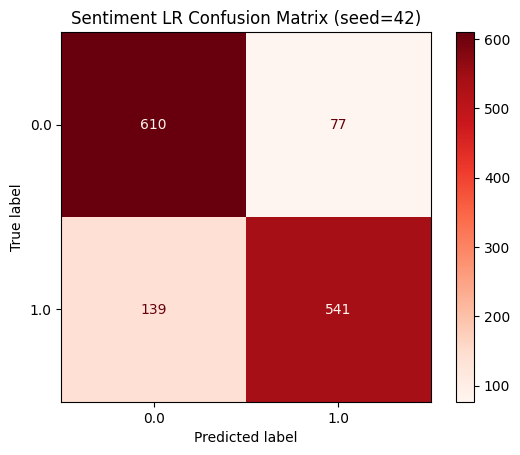


Sentiment LinearSVC | seed=42
SVM Confusion Matrix
[[604  83]
 [117 563]]
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86       687
         1.0       0.87      0.83      0.85       680

    accuracy                           0.85      1367
   macro avg       0.85      0.85      0.85      1367
weighted avg       0.85      0.85      0.85      1367

Accuracy: 0.8536942209217264
MCC: 0.7081834331500176
ROC AUC: 0.9290050518023804


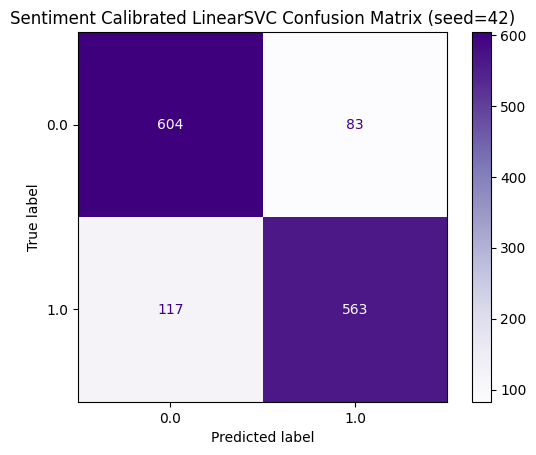


Sentiment Logistic Regression | seed=1234
LR Confusion Matrix
[[610  77]
 [139 541]]
              precision    recall  f1-score   support

         0.0       0.81      0.89      0.85       687
         1.0       0.88      0.80      0.83       680

    accuracy                           0.84      1367
   macro avg       0.84      0.84      0.84      1367
weighted avg       0.84      0.84      0.84      1367

Accuracy: 0.8419897585954645
MCC: 0.6866579746216862
ROC AUC: 0.9205390016268515


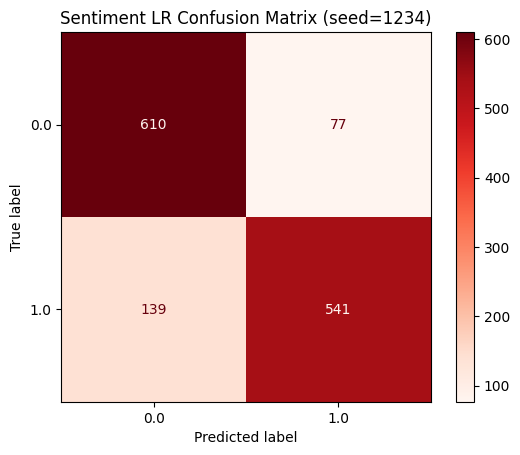


Sentiment LinearSVC | seed=1234
SVM Confusion Matrix
[[604  83]
 [117 563]]
              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86       687
         1.0       0.87      0.83      0.85       680

    accuracy                           0.85      1367
   macro avg       0.85      0.85      0.85      1367
weighted avg       0.85      0.85      0.85      1367

Accuracy: 0.8536942209217264
MCC: 0.7081834331500176
ROC AUC: 0.9290050518023804


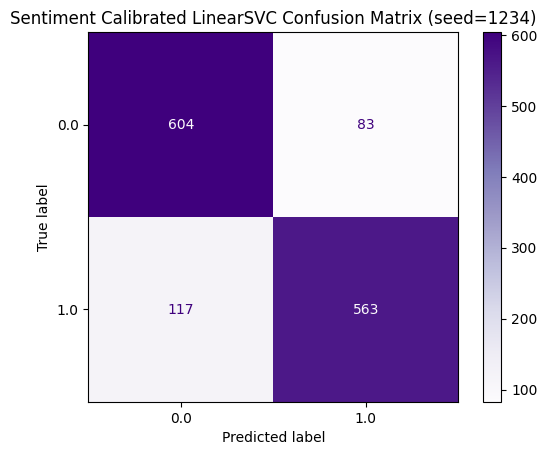

In [ ]:
# Sentiment + Logistic regression +SVM
sentiment_output = []

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"Sentiment Logistic Regression | seed={seed}")

    lr = LogisticRegression(random_state=seed,max_iter=1000,class_weight="balanced")
    lr.fit(X_train_sentiment, Y_train_sentiment)

    y_pred1 = lr.predict(X_test_sentiment)
    cm1 = confusion_matrix(Y_test_sentiment, y_pred1)
    print("LR Confusion Matrix")
    print(cm1)

    print(classification_report(Y_test_sentiment, y_pred1))
    print("Accuracy:", accuracy_score(Y_test_sentiment, y_pred1))
    print("MCC:", matthews_corrcoef(Y_test_sentiment, y_pred1))

    y_prob1 = lr.predict_proba(X_test_sentiment)
    roc_auc1 = roc_auc_score(Y_test_sentiment, y_prob1[:, 1])
    print("ROC AUC:", roc_auc1)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=lr.classes_)
    disp.plot(cmap="Reds")
    plt.title(f"Sentiment LR Confusion Matrix (seed={seed})")
    plt.show()

    sentiment_output.append({"model": "LogisticRegression","seed": seed,"accuracy": accuracy_score(Y_test_sentiment, y_pred1),"mcc": matthews_corrcoef(Y_test_sentiment, y_pred1),"roc_auc": roc_auc1})

    print(f"\nSentiment LinearSVC | seed={seed}")

    svm = CalibratedClassifierCV(LinearSVC(random_state=seed,class_weight="balanced",max_iter=10000))
    svm.fit(X_train_sentiment, Y_train_sentiment)

    y_pred2 = svm.predict(X_test_sentiment)
    cm2 = confusion_matrix(Y_test_sentiment, y_pred2)
    print("SVM Confusion Matrix")
    print(cm2)

    print(classification_report(Y_test_sentiment, y_pred2))
    print("Accuracy:", accuracy_score(Y_test_sentiment, y_pred2))
    print("MCC:", matthews_corrcoef(Y_test_sentiment, y_pred2))

    y_prob2 = svm.predict_proba(X_test_sentiment)
    roc_auc2 = roc_auc_score(Y_test_sentiment, y_prob2[:, 1])
    print("ROC AUC:", roc_auc2)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=svm.classes_)
    disp.plot(cmap="Purples")
    plt.title(f"Sentiment Calibrated LinearSVC Confusion Matrix (seed={seed})")
    plt.show()

    sentiment_output.append({"model": "Calibrated LinearSVC","seed": seed,"accuracy": accuracy_score(Y_test_sentiment, y_pred2),"mcc": matthews_corrcoef(Y_test_sentiment, y_pred2),"roc_auc": roc_auc2})


In [ ]:
# LR +SVM summary
for i in sentiment_output:
    print(i)


{'model': 'LogisticRegression', 'seed': 42, 'accuracy': 0.8419897585954645, 'mcc': np.float64(0.6866579746216862), 'roc_auc': np.float64(0.9205390016268515)}
{'model': 'Calibrated LinearSVC', 'seed': 42, 'accuracy': 0.8536942209217264, 'mcc': np.float64(0.7081834331500176), 'roc_auc': np.float64(0.9290050518023804)}
{'model': 'LogisticRegression', 'seed': 1234, 'accuracy': 0.8419897585954645, 'mcc': np.float64(0.6866579746216862), 'roc_auc': np.float64(0.9205390016268515)}
{'model': 'Calibrated LinearSVC', 'seed': 1234, 'accuracy': 0.8536942209217264, 'mcc': np.float64(0.7081834331500176), 'roc_auc': np.float64(0.9290050518023804)}



Sarcasm - Logistic Regression | seed=42
LR Confusion Matrix
[[850 268]
 [ 78 171]]
              precision    recall  f1-score   support

         0.0       0.92      0.76      0.83      1118
         1.0       0.39      0.69      0.50       249

    accuracy                           0.75      1367
   macro avg       0.65      0.72      0.66      1367
weighted avg       0.82      0.75      0.77      1367

Accuracy: 0.7468910021945867
MCC: 0.36953375774294817
ROC AUC: 0.8036008075234748


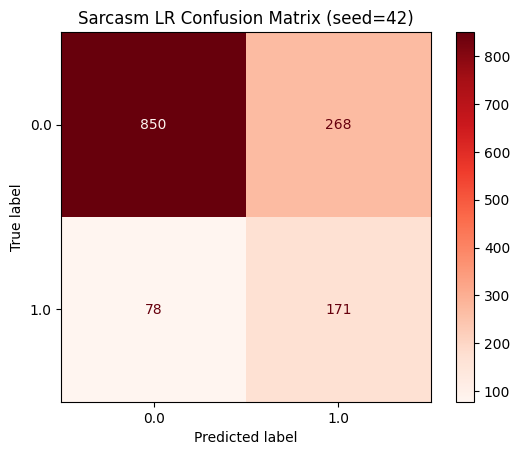


Sarcasm - Calibrated LinearSVC | seed=42
SVM Confusion Matrix
[[1091   27]
 [ 220   29]]
              precision    recall  f1-score   support

         0.0       0.83      0.98      0.90      1118
         1.0       0.52      0.12      0.19       249

    accuracy                           0.82      1367
   macro avg       0.68      0.55      0.54      1367
weighted avg       0.77      0.82      0.77      1367

Accuracy: 0.8193123628383321
MCC: 0.17976299273881607
ROC AUC: 0.7865415148967965


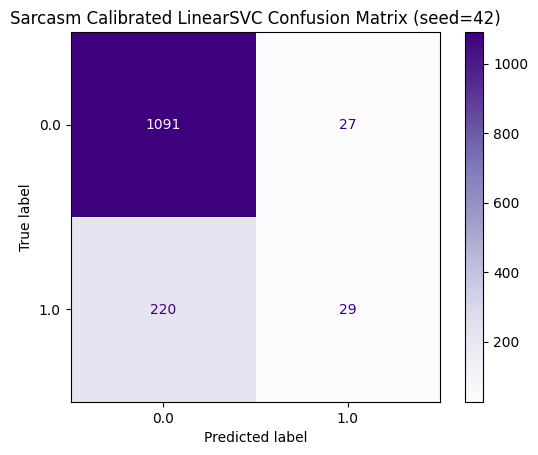


Sarcasm - Logistic Regression | seed=1234
LR Confusion Matrix
[[850 268]
 [ 78 171]]
              precision    recall  f1-score   support

         0.0       0.92      0.76      0.83      1118
         1.0       0.39      0.69      0.50       249

    accuracy                           0.75      1367
   macro avg       0.65      0.72      0.66      1367
weighted avg       0.82      0.75      0.77      1367

Accuracy: 0.7468910021945867
MCC: 0.36953375774294817
ROC AUC: 0.8036008075234748


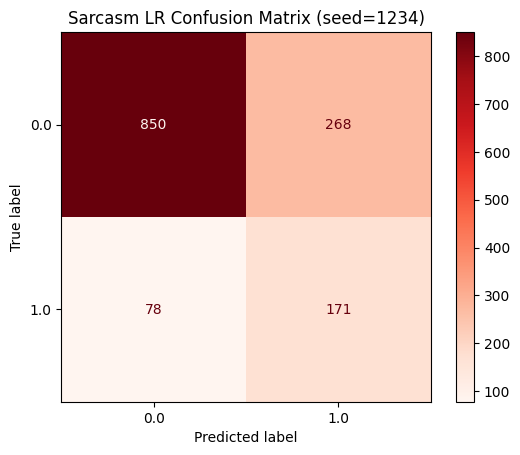


Sarcasm - Calibrated LinearSVC | seed=1234
SVM Confusion Matrix
[[1091   27]
 [ 220   29]]
              precision    recall  f1-score   support

         0.0       0.83      0.98      0.90      1118
         1.0       0.52      0.12      0.19       249

    accuracy                           0.82      1367
   macro avg       0.68      0.55      0.54      1367
weighted avg       0.77      0.82      0.77      1367

Accuracy: 0.8193123628383321
MCC: 0.17976299273881607
ROC AUC: 0.7865415148967965


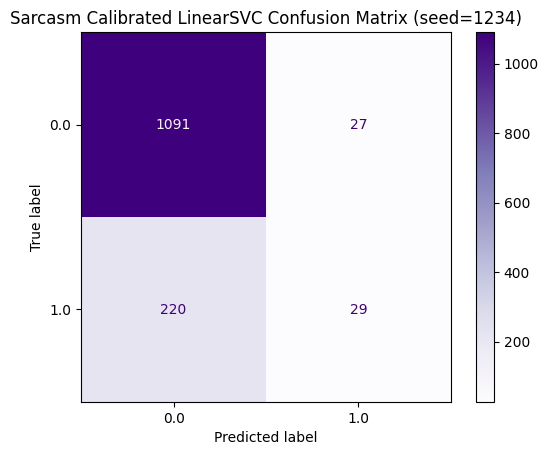

In [ ]:
# Sarcasm +Logistic Regression + SVM
sarcasm_output= []

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"Sarcasm - Logistic Regression | seed={seed}")

    lr = LogisticRegression(random_state=seed,max_iter=1000,class_weight="balanced")
    lr.fit(X_train_sarcasm, Y_train_sarcasm)

    y_pred3 = lr.predict(X_test_sarcasm)
    cm3 = confusion_matrix(Y_test_sarcasm, y_pred3)
    print("LR Confusion Matrix")
    print(cm3)

    print(classification_report(Y_test_sarcasm, y_pred3))
    print("Accuracy:", accuracy_score(Y_test_sarcasm, y_pred3))
    print("MCC:", matthews_corrcoef(Y_test_sarcasm, y_pred3))

    y_prob3 = lr.predict_proba(X_test_sarcasm)
    roc_auc3 = roc_auc_score(Y_test_sarcasm, y_prob3[:, 1])
    print("ROC AUC:", roc_auc3)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=lr.classes_)
    disp.plot(cmap="Reds")
    plt.title(f"Sarcasm LR Confusion Matrix (seed={seed})")
    plt.show()

    sarcasm_output.append({"model": "LogisticRegression","seed": seed,"accuracy": accuracy_score(Y_test_sarcasm, y_pred3),"mcc": matthews_corrcoef(Y_test_sarcasm, y_pred3),"roc_auc": roc_auc3})

    print(f"\nSarcasm - Calibrated LinearSVC | seed={seed}")

    svm = CalibratedClassifierCV(LinearSVC(random_state=seed,class_weight="balanced",max_iter=10000))
    svm.fit(X_train_sarcasm, Y_train_sarcasm)

    y_pred4 = svm.predict(X_test_sarcasm)
    cm4 = confusion_matrix(Y_test_sarcasm, y_pred4)
    print("SVM Confusion Matrix")
    print(cm4)

    print(classification_report(Y_test_sarcasm, y_pred4))
    print("Accuracy:", accuracy_score(Y_test_sarcasm, y_pred4))
    print("MCC:", matthews_corrcoef(Y_test_sarcasm, y_pred4))

    y_prob4 = svm.predict_proba(X_test_sarcasm)
    roc_auc4 = roc_auc_score(Y_test_sarcasm, y_prob4[:, 1])
    print("ROC AUC:", roc_auc4)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=svm.classes_)
    disp.plot(cmap="Purples")
    plt.title(f"Sarcasm Calibrated LinearSVC Confusion Matrix (seed={seed})")
    plt.show()

    sarcasm_output.append({"model": "Calibrated LinearSVC","seed": seed,"accuracy": accuracy_score(Y_test_sarcasm, y_pred4),"mcc": matthews_corrcoef(Y_test_sarcasm, y_pred4),"roc_auc": roc_auc4})


In [ ]:
# Sarcasm LR + SVM
print("Sarcasm results summary")
for i in sarcasm_output:
    print(i)


Sarcasm results summary
{'model': 'LogisticRegression', 'seed': 42, 'accuracy': 0.7468910021945867, 'mcc': np.float64(0.36953375774294817), 'roc_auc': np.float64(0.8036008075234748)}
{'model': 'Calibrated LinearSVC', 'seed': 42, 'accuracy': 0.8193123628383321, 'mcc': np.float64(0.17976299273881607), 'roc_auc': np.float64(0.7865415148967965)}
{'model': 'LogisticRegression', 'seed': 1234, 'accuracy': 0.7468910021945867, 'mcc': np.float64(0.36953375774294817), 'roc_auc': np.float64(0.8036008075234748)}
{'model': 'Calibrated LinearSVC', 'seed': 1234, 'accuracy': 0.8193123628383321, 'mcc': np.float64(0.17976299273881607), 'roc_auc': np.float64(0.7865415148967965)}
